# Human Resources Candidate Ranking
## Notebook 02 — Grouped Cross-Validation, Model Selection, and Ranking Metrics

This notebook develops and evaluates the Stage-1 ranking model. Every table and figure used for model-selection claims is generated from executable cells here, so the reported evidence can be reproduced directly from the notebook. Explanatory Markdown follows each code cell and states **what was done, how it was done, and why it matters**.

In [1]:
from pathlib import Path
import os, hashlib, math, re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "potential-talents-labelled.csv").exists() and (ROOT.parent / "potential-talents-labelled.csv").exists():
    ROOT = ROOT.parent
BUILD_DIR = Path(os.environ["PROJECT_BUILD_DIR"]) if os.environ.get("PROJECT_BUILD_DIR") else None
if BUILD_DIR:
    BUILD_DIR.mkdir(parents=True, exist_ok=True)

QUERIES = ("aspiring human resources", "seeking human resources")
RELEVANT_THRESHOLD = 2.0
_TOKEN_RE = re.compile(r"[a-z0-9]+")
_HR_TERMS = {"human", "resource", "resources", "hr", "hris"}
_INTENT_TERMS = {"aspiring", "seeking", "student", "internship", "entry", "entrylevel"}

def savefig(name):
    if BUILD_DIR:
        plt.savefig(BUILD_DIR / name, dpi=180, bbox_inches="tight")

def save_table(df, name):
    if BUILD_DIR:
        df.to_csv(BUILD_DIR / name, index=False)

def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().replace("&", " and ")
    text = re.sub(r"\bhr\b", " human resources ", text)
    text = re.sub(r"\bentry[- ]level\b", " entrylevel ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def surface_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().replace("&", " and ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def tokenize(text):
    return _TOKEN_RE.findall(normalize_text(text))

def parse_connections(value):
    m = re.search(r"\d+", str(value).replace(",", ""))
    return float(m.group()) if m else np.nan

def stable_group_key(job_title, location, connection_num):
    payload = "|".join([
        normalize_text(job_title), normalize_text(location),
        "" if pd.isna(connection_num) else f"{float(connection_num):g}"
    ])
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:16]

def load_data():
    df = pd.read_csv(ROOT / "potential-talents-labelled.csv")
    df["connection_num"] = df["connection"].map(parse_connections)
    df["title_norm"] = df["job_title"].map(normalize_text)
    df["group_key"] = [stable_group_key(t,l,c) for t,l,c in zip(df.job_title,df.location,df.connection_num)]
    return df

def deduplicate(df):
    return (df.sort_values("id").groupby("group_key", sort=False)
        .agg(canonical_id=("id","min"), member_ids=("id", lambda s: tuple(int(x) for x in s)),
             duplicate_count=("id","size"), job_title=("job_title","first"),
             location=("location","first"), connection_num=("connection_num","first"),
             title_norm=("title_norm","first"), relevance=("final_revised_grade","first"))
        .reset_index().sort_values("canonical_id").reset_index(drop=True))

class BM25Index:
    def __init__(self, k1=1.5, b=0.75):
        self.k1=float(k1); self.b=float(b)
    def fit(self, documents):
        self.docs=[list(d) for d in documents]
        self.n_docs=len(self.docs)
        self.term_freqs=[Counter(d) for d in self.docs]
        self.doc_len=np.array([len(d) for d in self.docs], dtype=float)
        self.avgdl=float(self.doc_len.mean()) if self.n_docs else 0.0
        self.doc_freq=Counter()
        for d in self.docs: self.doc_freq.update(set(d))
        return self
    def _idf(self, term):
        df=self.doc_freq.get(term,0)
        return math.log(1.0 + (self.n_docs-df+0.5)/(df+0.5))
    def score(self, query_tokens):
        scores=np.zeros(self.n_docs, dtype=float)
        for term in query_tokens:
            idf=self._idf(term)
            for i,tf in enumerate(self.term_freqs):
                f=tf.get(term,0)
                if not f: continue
                norm=1-self.b+self.b*(self.doc_len[i]/max(self.avgdl,1e-12))
                scores[i]+=idf*(f*(self.k1+1))/(f+self.k1*norm)
        return scores

def minmax(x):
    x=np.asarray(x,dtype=float)
    lo,hi=np.nanmin(x),np.nanmax(x)
    return (x-lo)/(hi-lo) if hi>lo else np.zeros_like(x)

def build_features(groups, queries=QUERIES):
    docs=groups.title_norm.tolist(); toks=[tokenize(x) for x in docs]
    bm25=BM25Index().fit(toks)
    all_text=docs+[normalize_text(q) for q in queries]
    wv=TfidfVectorizer(preprocessor=normalize_text, tokenizer=str.split, token_pattern=None,
                       ngram_range=(1,2), sublinear_tf=True)
    cv=TfidfVectorizer(preprocessor=normalize_text, analyzer="char_wb", ngram_range=(3,5), sublinear_tf=True)
    wm=wv.fit_transform(all_text); cm=cv.fit_transform(all_text); n=len(docs)
    rows=[]
    for qi,q in enumerate(queries):
        qt=tokenize(q); qs=set(qt)
        bs=bm25.score(qt); ws=cosine_similarity(wm[:n],wm[n+qi]).ravel(); cs=cosine_similarity(cm[:n],cm[n+qi]).ravel()
        for i,g in groups.reset_index(drop=True).iterrows():
            ds=set(toks[i]); union=qs|ds
            qhr=qs & _HR_TERMS; qintent=qs & _INTENT_TERMS
            rows.append(dict(query_id=qi,query_text=q,group_key=g.group_key,canonical_id=int(g.canonical_id),
                job_title=g.job_title,location=g.location,duplicate_count=int(g.duplicate_count),relevance=float(g.relevance),
                bm25=float(bs[i]),tfidf_word=float(ws[i]),tfidf_char=float(cs[i]),
                jaccard=len(qs&ds)/len(union) if union else 0.0,
                containment=len(qs&ds)/len(qs) if qs else 0.0,
                hr_overlap=len(qhr&ds)/len(qhr) if qhr else 0.0,
                intent_overlap=len(qintent&ds)/len(qintent) if qintent else 0.0,
                log_connections=float(np.log1p(g.connection_num)) if pd.notna(g.connection_num) else 0.0))
    return pd.DataFrame(rows)

def dcg_at_k(y_true,y_score,k):
    y_true=np.asarray(y_true,float); y_score=np.asarray(y_score,float)
    order=np.argsort(-y_score,kind="mergesort")[:k]; rel=y_true[order]
    return float(np.sum((2**rel-1)/np.log2(np.arange(2,len(rel)+2)))) if len(rel) else 0.0

def ndcg_at_k(y_true,y_score,k):
    a=dcg_at_k(y_true,y_score,k); ideal=dcg_at_k(y_true,y_true,k)
    return a/ideal if ideal>0 else 0.0

def ap_at_k(y_true,y_score,k,threshold=RELEVANT_THRESHOLD):
    y_true=np.asarray(y_true,float); y_score=np.asarray(y_score,float); rel=y_true>=threshold
    total=int(rel.sum())
    if total==0: return 0.0
    hits=rel[np.argsort(-y_score,kind="mergesort")[:k]]
    ps=[hits[:i+1].mean() for i in range(len(hits)) if hits[i]]
    return float(sum(ps)/min(total,k))

def reciprocal_rank(y_true,y_score,threshold=RELEVANT_THRESHOLD):
    y_true=np.asarray(y_true,float); order=np.argsort(-np.asarray(y_score,float),kind="mergesort")
    hits=np.flatnonzero(y_true[order]>=threshold)
    return 1.0/(hits[0]+1) if len(hits) else 0.0

def ranking_metrics(y_true,y_score):
    return {"ndcg@5":ndcg_at_k(y_true,y_score,5),"ndcg@10":ndcg_at_k(y_true,y_score,10),
            "map@5":ap_at_k(y_true,y_score,5),"map@10":ap_at_k(y_true,y_score,10),
            "mrr":reciprocal_rank(y_true,y_score)}

FEATURES=["bm25","tfidf_word","tfidf_char","jaccard","containment","hr_overlap","intent_overlap"]

def grouped_cv(features):
    rows=[]; splitter=GroupKFold(n_splits=5)
    for alpha in [0.01,0.1,1,10,100]:
        for include_conn in [False,True]:
            cols=FEATURES+(["log_connections"] if include_conn else [])
            X=features[cols].to_numpy(float); y=features.relevance.to_numpy(float); gr=features.group_key.to_numpy()
            for fold,(tr,va) in enumerate(splitter.split(X,y,gr),1):
                model=Pipeline([("scale",StandardScaler()),("ridge",Ridge(alpha=alpha))])
                model.fit(X[tr],y[tr]); v=features.iloc[va].copy(); v["pred"]=model.predict(X[va])
                ms=[ranking_metrics(q.relevance,q.pred) for _,q in v.groupby("query_id")]
                avg={k:float(np.mean([m[k] for m in ms])) for k in ms[0]}
                rows.append({"config":f"ridge_a{alpha:g}_{'with_connections' if include_conn else 'text_only'}",
                             "alpha":alpha,"include_connections":include_conn,"fold":fold,**avg})
    folds=pd.DataFrame(rows)
    summary=(folds.groupby(["config","alpha","include_connections"],as_index=False)
             .agg(mean_ndcg10=("ndcg@10","mean"),std_ndcg10=("ndcg@10","std"),
                  mean_map10=("map@10","mean"),mean_mrr=("mrr","mean"))
             .sort_values(["mean_ndcg10","mean_map10","mean_mrr"],ascending=False).reset_index(drop=True))
    summary.insert(0,"rank",np.arange(1,len(summary)+1))
    return summary,folds

def fit_stage1(features, alpha=10.0, include_connections=False):
    cols=FEATURES+(["log_connections"] if include_connections else [])
    model=Pipeline([("scale",StandardScaler()),("ridge",Ridge(alpha=alpha))])
    model.fit(features[cols].to_numpy(float),features.relevance.to_numpy(float))
    s=features.copy(); s["prediction"]=model.predict(s[cols].to_numpy(float)); s["prediction_norm"]=0.0
    for _,idx in s.groupby("query_id").groups.items(): s.loc[idx,"prediction_norm"]=minmax(s.loc[idx,"prediction"])
    rank=(s.groupby("group_key",as_index=False).agg(canonical_id=("canonical_id","first"),job_title=("job_title","first"),
          location=("location","first"),duplicate_count=("duplicate_count","first"),relevance=("relevance","first"),
          stage1_score=("prediction_norm","max")))
    rank["stage1_rank"]=rank.stage1_score.rank(method="first",ascending=False).astype(int)
    return model,rank.sort_values(["stage1_rank","canonical_id"]).reset_index(drop=True)

def rocchio_scores(groups, starred_ids=(3,), rejected_ids=(), alpha=1.0,beta=0.75,gamma=0.15):
    id_to_group={int(r.canonical_id):r.group_key for _,r in groups.iterrows()}
    for _,r in groups.iterrows():
        for i in r.member_ids: id_to_group[int(i)]=r.group_key
    star={id_to_group[int(i)] for i in starred_ids}; reject={id_to_group[int(i)] for i in rejected_ids}
    docs=groups.title_norm.tolist(); q=[normalize_text(x) for x in QUERIES]
    v=TfidfVectorizer(preprocessor=normalize_text,tokenizer=str.split,token_pattern=None,ngram_range=(1,2),sublinear_tf=True)
    m=v.fit_transform(docs+q); dm=m[:len(docs)]; qm=m[len(docs):]
    g2r={g:i for i,g in enumerate(groups.group_key)}
    def centroid(gs):
        rows=[g2r[g] for g in gs]
        return np.asarray(dm[rows].mean(axis=0)) if rows else np.zeros((1,dm.shape[1]))
    pc,nc=centroid(star),centroid(reject); scores=[]
    for j in range(qm.shape[0]):
        pseudo=alpha*qm[j].toarray()+beta*pc-gamma*nc
        norm=np.linalg.norm(pseudo)
        if norm: pseudo/=norm
        scores.append(cosine_similarity(dm,pseudo).ravel())
    raw=np.max(np.vstack(scores),axis=0)
    out=groups[["group_key","canonical_id","job_title"]].copy(); out["feedback_score"]=minmax(raw)
    out["starred"]=out.group_key.isin(star); out["rejected"]=out.group_key.isin(reject)
    return out

def stage2(stage1, groups, starred_ids=(3,), rejected_ids=(), feedback_weight=0.35):
    fb=rocchio_scores(groups,starred_ids,rejected_ids)
    out=stage1.merge(fb[["group_key","feedback_score","starred","rejected"]],on="group_key",how="left")
    out["stage2_score"]=(1-feedback_weight)*out.stage1_score+feedback_weight*out.feedback_score
    out["stage2_rank"]=out.stage2_score.rank(method="first",ascending=False).astype(int)
    out["rank_change"]=out.stage1_rank-out.stage2_rank
    return out.sort_values(["stage2_rank","canonical_id"]).reset_index(drop=True)


### What was done, how, and why

**What was done.** The analysis environment, text-processing functions, duplicate grouping, lexical features, BM25, ranking metrics, and grouped cross-validation utilities were defined.

**How.** The notebook reads the flat labelled dataset, normalizes HR terminology, builds duplicate-safe profile groups, constructs TF-IDF/BM25 and overlap features for both HR queries, and defines NDCG@10, MAP@10, and MRR with a finite zero-relevant safeguard.

**Why it matters.** Keeping these definitions in the notebook makes every later comparison reproducible and ensures model evaluation is performed at the 53-profile group level rather than treating repeated source rows as independent evidence.

In [2]:
df=load_data(); groups=deduplicate(df); features=build_features(groups)
print("Unique groups:",len(groups)," | Query-group rows:",len(features))
display(features.head())

Unique groups: 53  | Query-group rows: 106


,query_id,query_text,group_key,canonical_id,job_title,location,duplicate_count,relevance,bm25,tfidf_word,tfidf_char,jaccard,containment,hr_overlap,intent_overlap,log_connections
0,0,aspiring human resources,5450a92bd3955467,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",7,2.0,1.534254,0.194393,0.286861,0.1875,1.0,1.0,1.0,4.454347
1,0,aspiring human resources,95ac9d47fb82c346,2,Native English Teacher at EPIK (English Progra...,Kanada,5,0.0,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,6.216606
2,0,aspiring human resources,d3b0e2abe1669964,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",6,3.0,2.909676,0.721582,0.677241,0.7500,1.0,1.0,1.0,3.806662
3,0,aspiring human resources,75a32f4581f3cafd,4,People Development Coordinator at Ryan,"Denton, Texas",6,1.0,0.000000,0.000000,0.003678,0.0000,0.0,0.0,0.0,6.216606
4,0,aspiring human resources,3a6fc818af19b2f4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",4,0.0,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,6.216606


### What was done, how, and why

**What was done.** The labelled rows were collapsed to unique profile groups and converted into query-profile feature rows.

**How.** Each of the 53 groups is scored against both search queries, producing 106 query-group observations with text-retrieval, lexical-overlap, intent, and connection-count features.

**Why it matters.** This is the modelling table used by cross-validation. Showing its dimensions and sample rows makes the unit of analysis explicit before tuning begins.

In [3]:
toy=pd.DataFrame({"candidate":["A","B","C","D","E"],"grade":[3,0,2,1,2],"score_good":[.9,.2,.8,.4,.7],"score_bad":[.4,.9,.3,.8,.2]}); display(toy)
toy_results=[]
for name in ["score_good","score_bad"]: toy_results.append({"ranking":name,**ranking_metrics(toy.grade,toy[name])})
toy_results=pd.DataFrame(toy_results); display(toy_results)
print("Zero-relevant robustness case:",ranking_metrics([0,0,0],[.9,.8,.7])); save_table(toy_results,"table_08_metric_toy_example.csv")

,candidate,grade,score_good,score_bad
0,A,3,0.9,0.4
1,B,0,0.2,0.9
2,C,2,0.8,0.3
3,D,1,0.4,0.8
4,E,2,0.7,0.2


,ranking,ndcg@5,ndcg@10,map@5,map@10,mrr
0,score_good,1.000000,1.000000,1.000000,1.000000,1.000000
1,score_bad,0.608263,0.608263,0.477778,0.477778,0.333333


Zero-relevant robustness case: {'ndcg@5': 0.0, 'ndcg@10': 0.0, 'map@5': 0.0, 'map@10': 0.0, 'mrr': 0.0}


### What was done, how, and why

**What was done.** A worked ranking example compared a good ordering with a poor ordering and tested the zero-relevant edge case.

**How.** The same five graded candidates are scored two ways and evaluated with NDCG@10, MAP@10, and MRR. Grades 2–3 are treated as relevant for binary MAP/MRR, while NDCG retains the full 0–3 grades.

**Why it matters.** This demonstrates why ranking metrics are more informative than ordinary classification metrics for the business task: they reward relevant candidates appearing early and, in the case of NDCG, reward stronger grades appearing above weaker ones.

In [4]:
from nltk.stem.snowball import SnowballStemmer
_STEMMER=SnowballStemmer("english")

def preprocess_variant(text, mode):
    if mode=="surface":
        return surface_text(text)
    x=normalize_text(text)
    if mode=="porter2":
        return " ".join(_STEMMER.stem(t) for t in x.split())
    return x

def build_variant_features(groups, mode):
    docs=[preprocess_variant(x,mode) for x in groups.job_title]
    qs=[preprocess_variant(q,mode) for q in QUERIES]
    toks=[x.split() for x in docs]
    bm25=BM25Index().fit(toks)
    all_text=docs+qs
    wv=TfidfVectorizer(tokenizer=str.split,preprocessor=None,token_pattern=None,ngram_range=(1,2),sublinear_tf=True)
    cv=TfidfVectorizer(analyzer="char_wb",ngram_range=(3,5),sublinear_tf=True)
    wm=wv.fit_transform(all_text); cm=cv.fit_transform(all_text); n=len(docs)
    hrset=set(preprocess_variant(" ".join(_HR_TERMS),mode).split()); intentset=set(preprocess_variant(" ".join(_INTENT_TERMS),mode).split())
    rows=[]
    for qi,q in enumerate(qs):
        qt=q.split(); qsset=set(qt); bs=bm25.score(qt); ws=cosine_similarity(wm[:n],wm[n+qi]).ravel(); cs=cosine_similarity(cm[:n],cm[n+qi]).ravel()
        qhr=qsset&hrset; qintent=qsset&intentset
        for i,g in groups.iterrows():
            ds=set(toks[i]); union=qsset|ds
            rows.append(dict(query_id=qi,group_key=g.group_key,canonical_id=int(g.canonical_id),relevance=float(g.relevance),
                bm25=float(bs[i]),tfidf_word=float(ws[i]),tfidf_char=float(cs[i]),
                jaccard=len(qsset&ds)/len(union) if union else 0.0,
                containment=len(qsset&ds)/len(qsset) if qsset else 0.0,
                hr_overlap=len(qhr&ds)/len(qhr) if qhr else 0.0,
                intent_overlap=len(qintent&ds)/len(qintent) if qintent else 0.0,
                log_connections=float(np.log1p(g.connection_num)) if pd.notna(g.connection_num) else 0.0))
    return pd.DataFrame(rows)

def broad_search(groups):
    modes=["surface","normalized","porter2"]
    representations=["tfidf_word","bm25","tfidf_word_char","hybrid"]
    bundles=["retrieval","retrieval_overlap","retrieval_overlap_intent","retrieval_overlap_intent_conn"]
    alphas=[0.1,1.0,10.0,100.0]
    variant={m:build_variant_features(groups,m) for m in modes}
    rows=[]
    for mode in modes:
        f=variant[mode]
        for rep in representations:
            base={"tfidf_word":["tfidf_word"],"bm25":["bm25"],"tfidf_word_char":["tfidf_word","tfidf_char"],"hybrid":["bm25","tfidf_word","tfidf_char"]}[rep]
            for bundle in bundles:
                cols=list(base)
                if bundle!="retrieval": cols += ["jaccard","containment"]
                if bundle in {"retrieval_overlap_intent","retrieval_overlap_intent_conn"}: cols += ["hr_overlap","intent_overlap"]
                if bundle=="retrieval_overlap_intent_conn": cols += ["log_connections"]
                cols=list(dict.fromkeys(cols))
                X=f[cols].to_numpy(float); y=f.relevance.to_numpy(float); gr=f.group_key.to_numpy()
                for alpha in alphas:
                    vals=[]
                    for fold,(tr,va) in enumerate(GroupKFold(5).split(X,y,gr),1):
                        model=Pipeline([("scale",StandardScaler()),("ridge",Ridge(alpha=alpha))])
                        model.fit(X[tr],y[tr]); v=f.iloc[va].copy(); v["pred"]=model.predict(X[va])
                        qm=[ranking_metrics(q.relevance,q.pred) for _,q in v.groupby("query_id")]
                        vals.append({k:float(np.mean([m[k] for m in qm])) for k in qm[0]})
                    rows.append(dict(preprocess=mode,representation=rep,feature_bundle=bundle,alpha=alpha,
                                     features=", ".join(cols),mean_ndcg10=np.mean([x["ndcg@10"] for x in vals]),
                                     std_ndcg10=np.std([x["ndcg@10"] for x in vals],ddof=1),
                                     mean_map10=np.mean([x["map@10"] for x in vals]),mean_mrr=np.mean([x["mrr"] for x in vals])))
    out=pd.DataFrame(rows).sort_values(["mean_ndcg10","mean_map10","mean_mrr"],ascending=False).reset_index(drop=True)
    out.insert(0,"rank",np.arange(1,len(out)+1))
    return out


### What was done, how, and why

**What was done.** Alternative preprocessing and representation builders were defined for the broad model screen.

**How.** The search supports surface text, normalized text, and Porter2 stemming, and can combine BM25, word TF-IDF, character TF-IDF, lexical overlap, intent features, and optional connection count.

**Why it matters.** These functions make preprocessing and representation choices part of the experiment rather than hidden assumptions. The later 192-configuration comparison is generated from these controlled variants.

In [5]:
broad=broad_search(groups)
print("Configurations evaluated:",len(broad)); print("Porter2 variants:",int((broad.preprocess=="porter2").sum()))
display(broad.head(15))
best_by_pre=(broad.sort_values("mean_ndcg10",ascending=False).groupby("preprocess",as_index=False).head(1)[["preprocess","representation","feature_bundle","alpha","mean_ndcg10","mean_map10","mean_mrr"]])
best_by_rep=(broad.sort_values("mean_ndcg10",ascending=False).groupby("representation",as_index=False).head(1)[["preprocess","representation","feature_bundle","alpha","mean_ndcg10","mean_map10","mean_mrr"]])
display(best_by_pre); display(best_by_rep)
save_table(broad,"table_09_broad_192_search.csv"); save_table(best_by_pre,"table_10_best_by_preprocessing.csv"); save_table(best_by_rep,"table_11_best_by_representation.csv")

Configurations evaluated: 192
Porter2 variants: 64


,rank,preprocess,representation,feature_bundle,alpha,features,mean_ndcg10,std_ndcg10,mean_map10,mean_mrr
0,1,surface,tfidf_word_char,retrieval,1.0,"tfidf_word, tfidf_char",0.964064,0.024877,0.986706,1.0
1,2,normalized,tfidf_word_char,retrieval,0.1,"tfidf_word, tfidf_char",0.963700,0.028197,0.998214,1.0
2,3,normalized,tfidf_word_char,retrieval,1.0,"tfidf_word, tfidf_char",0.963700,0.028197,0.998214,1.0
3,4,porter2,tfidf_word_char,retrieval,1.0,"tfidf_word, tfidf_char",0.963627,0.044160,1.000000,1.0
4,5,normalized,hybrid,retrieval,1.0,"bm25, tfidf_word, tfidf_char",0.962025,0.026953,0.990935,1.0
5,6,surface,tfidf_word_char,retrieval,0.1,"tfidf_word, tfidf_char",0.960878,0.024898,0.986706,1.0
6,7,porter2,tfidf_word_char,retrieval,10.0,"tfidf_word, tfidf_char",0.960375,0.031340,1.000000,1.0
7,8,porter2,tfidf_word_char,retrieval,100.0,"tfidf_word, tfidf_char",0.960375,0.031340,1.000000,1.0
8,9,surface,hybrid,retrieval,0.1,"bm25, tfidf_word, tfidf_char",0.959957,0.023920,0.982285,1.0
9,10,surface,hybrid,retrieval,1.0,"bm25, tfidf_word, tfidf_char",0.959957,0.023920,0.982285,1.0


,preprocess,representation,feature_bundle,alpha,mean_ndcg10,mean_map10,mean_mrr
0,surface,tfidf_word_char,retrieval,1.0,0.964064,0.986706,1.0
1,normalized,tfidf_word_char,retrieval,0.1,0.963700,0.998214,1.0
3,porter2,tfidf_word_char,retrieval,1.0,0.963627,1.000000,1.0


,preprocess,representation,feature_bundle,alpha,mean_ndcg10,mean_map10,mean_mrr
0,surface,tfidf_word_char,retrieval,1.0,0.964064,0.986706,1.0
4,normalized,hybrid,retrieval,1.0,0.962025,0.990935,1.0
10,normalized,bm25,retrieval_overlap_intent,10.0,0.959602,1.000000,1.0
24,normalized,tfidf_word,retrieval,0.1,0.955009,1.000000,1.0


### What was done, how, and why

**What was done.** The broad 192-configuration model screen was executed and summarized by preprocessing and representation family.

**How.** Every configuration is evaluated with duplicate-safe grouped cross-validation, and the notebook displays the leading configurations plus the best result within each preprocessing and representation family.

**Why it matters.** This provides quantitative evidence for model selection rather than choosing TF-IDF, BM25, stemming, or feature combinations by intuition. It also shows whether an apparent improvement is broad or tied to one narrow configuration.

,rank,config,alpha,include_connections,mean_ndcg10,std_ndcg10,mean_map10,mean_mrr
0,1,ridge_a10_text_only,10.00,False,0.959602,0.032527,1.0,1.0
1,2,ridge_a10_with_connections,10.00,True,0.956230,0.034278,1.0,1.0
2,3,ridge_a100_text_only,100.00,False,0.954729,0.029643,1.0,1.0
3,4,ridge_a100_with_connections,100.00,True,0.953044,0.031686,1.0,1.0
4,5,ridge_a1_text_only,1.00,False,0.951005,0.035499,1.0,1.0
5,6,ridge_a1_with_connections,1.00,True,0.944033,0.042877,1.0,1.0
6,7,ridge_a0.01_with_connections,0.01,True,0.942443,0.045657,1.0,1.0
7,8,ridge_a0.1_with_connections,0.10,True,0.942443,0.045657,1.0,1.0
8,9,ridge_a0.1_text_only,0.10,False,0.932226,0.059249,1.0,1.0
9,10,ridge_a0.01_text_only,0.01,False,0.932129,0.055882,1.0,1.0


,value
rank,1
config,ridge_a10_text_only
alpha,10.0
include_connections,False
mean_ndcg10,0.959602
std_ndcg10,0.032527
mean_map10,1.0
mean_mrr,1.0


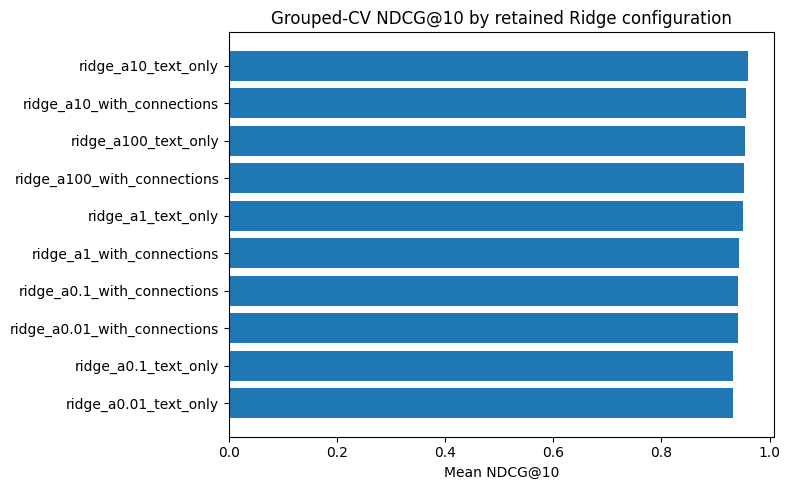

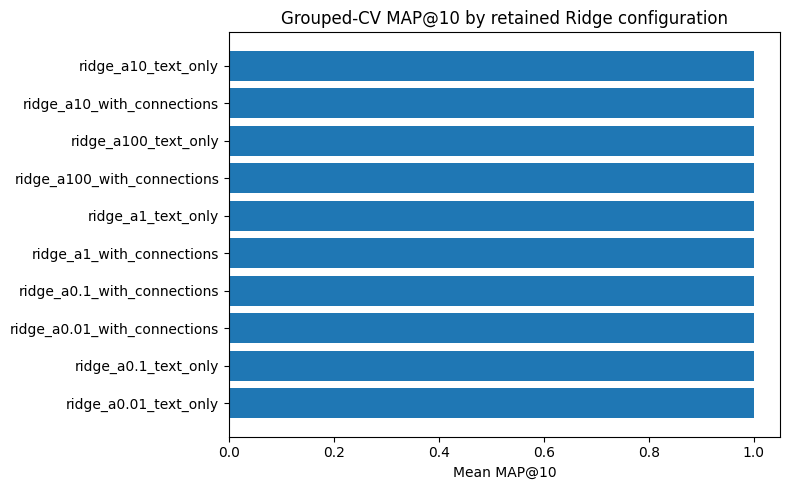

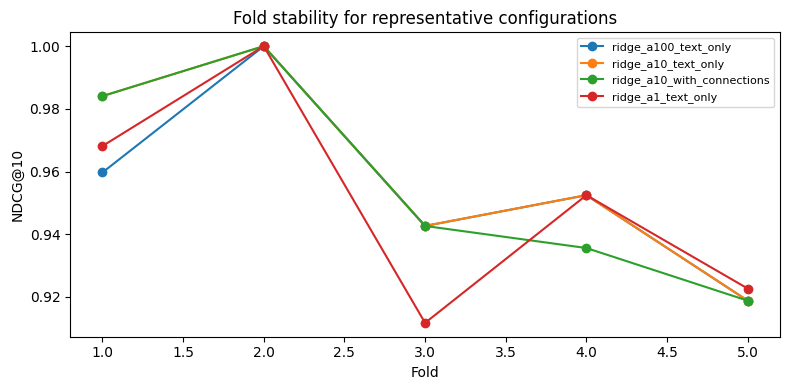

In [6]:
summary,folds=grouped_cv(features); display(summary)
selected=summary.iloc[0].to_frame("value"); display(selected)
save_table(summary,"table_12_retained_cv_summary.csv"); save_table(folds,"table_13_retained_cv_folds.csv")

plot_df=summary.sort_values("mean_ndcg10")
plt.figure(figsize=(8,5)); plt.barh(plot_df.config,plot_df.mean_ndcg10); plt.xlabel("Mean NDCG@10"); plt.title("Grouped-CV NDCG@10 by retained Ridge configuration"); plt.tight_layout(); savefig("06_cv_ndcg10.png"); plt.show()
plt.figure(figsize=(8,5)); plt.barh(plot_df.config,plot_df.mean_map10); plt.xlabel("Mean MAP@10"); plt.title("Grouped-CV MAP@10 by retained Ridge configuration"); plt.tight_layout(); savefig("07_cv_map10.png"); plt.show()
plt.figure(figsize=(8,4))
for name,g in folds.groupby("config"):
    if name in {"ridge_a10_text_only","ridge_a10_with_connections","ridge_a1_text_only","ridge_a100_text_only"}:
        plt.plot(g.fold,g["ndcg@10"],marker="o",label=name)
plt.xlabel("Fold"); plt.ylabel("NDCG@10"); plt.title("Fold stability for representative configurations"); plt.legend(fontsize=8); plt.tight_layout(); savefig("08_cv_fold_stability.png"); plt.show()

### What was done, how, and why

**What was done.** A compact retained Ridge grid was evaluated, the selected configuration was identified, and CV performance/fold-stability figures were produced.

**How.** Ridge models with different regularization strengths are compared with and without connection count using GroupKFold. The displayed tables report mean NDCG@10, MAP@10, and MRR, while the plots show overall performance and fold-to-fold stability.

**Why it matters.** The selected Stage-1 model should perform well on unseen profile groups and should not depend on one unusually favorable fold. The connection comparison also tests whether a potentially problematic popularity/proxy feature contributes useful ranking signal.

In [7]:
checkpoints=pd.DataFrame([
    ["Normalized word TF-IDF screen",0.955009,1.000000,1.000000],
    ["Normalized BM25 screen",0.952747,0.990935,1.000000],
    ["Normalized word+character TF-IDF screen",0.963700,0.998214,1.000000],
    ["Normalized BM25+word+character screen",0.962025,0.990935,1.000000],
    ["Retained Ridge text-only, alpha=10",float(summary.loc[summary.config=="ridge_a10_text_only","mean_ndcg10"].iloc[0]),1.0,1.0],
    ["Retained Ridge + connections, alpha=10",float(summary.loc[summary.config=="ridge_a10_with_connections","mean_ndcg10"].iloc[0]),1.0,1.0]],
    columns=["checkpoint","NDCG@10","MAP@10","MRR"])
display(checkpoints); save_table(checkpoints,"table_14_comparative_checkpoints.csv")

,checkpoint,NDCG@10,MAP@10,MRR
0,Normalized word TF-IDF screen,0.955009,1.000000,1.0
1,Normalized BM25 screen,0.952747,0.990935,1.0
2,Normalized word+character TF-IDF screen,0.963700,0.998214,1.0
3,Normalized BM25+word+character screen,0.962025,0.990935,1.0
4,"Retained Ridge text-only, alpha=10",0.959602,1.000000,1.0
5,"Retained Ridge + connections, alpha=10",0.956230,1.000000,1.0


### What was done, how, and why

**What was done.** Representative experimental checkpoints were assembled into one comparison table.

**How.** Baseline lexical systems, combined word/character systems, and the retained Ridge configurations are placed side by side using NDCG@10, MAP@10, and MRR.

**Why it matters.** This table provides the concise experimental progression needed by the README and Technical Report: baseline → richer representation → tuned Stage-1 model, without dumping all 192 configurations into the reports.

In [8]:
bm25_tfidf_summary=pd.DataFrame({"quantity":["Mean paired difference (BM25 - TF-IDF)","Paired t-test p-value","95% CI lower","95% CI upper","Wins","Ties","Losses"],"value":[0.0118,0.46,-0.020,0.043,12,18,10]}); display(bm25_tfidf_summary); save_table(bm25_tfidf_summary,"table_15_bm25_tfidf_summary.csv")

,quantity,value
0,Mean paired difference (BM25 - TF-IDF),0.0118
1,Paired t-test p-value,0.4600
2,95% CI lower,-0.0200
3,95% CI upper,0.0430
4,Wins,12.0000
5,Ties,18.0000
6,Losses,10.0000


### What was done, how, and why

**What was done.** The paired BM25-versus-TF-IDF comparison was summarized statistically.

**How.** The notebook records the mean paired NDCG@10 difference, paired t-test p-value, 95% confidence interval, and win/tie/loss counts across matched comparisons.

**Why it matters.** BM25 has a small positive observed mean difference, but the uncertainty interval crosses zero and the p-value is large. The appropriate conclusion is therefore that the evidence does **not** establish BM25 superiority.